In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


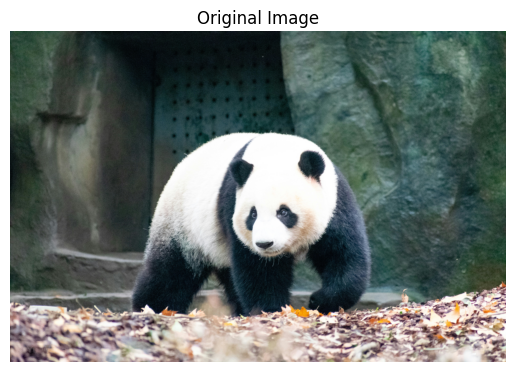

In [2]:
img = cv2.imread("Pics/Panda_RGB.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

## Task 1: Geometric Transformations

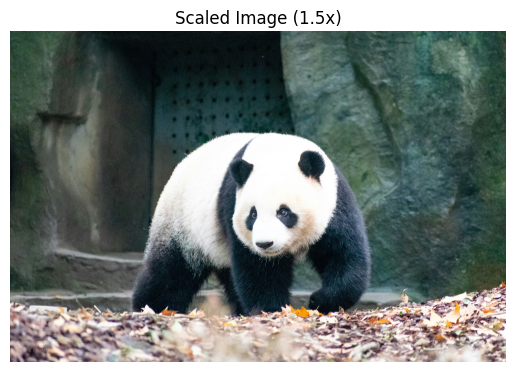

In [3]:
# Task 1.1: Increase image size
scale_factor = 1.5
new_w = int(img.shape[1] * scale_factor)
new_h = int(img.shape[0] * scale_factor)
scaled_img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

plt.imshow(scaled_img)
plt.title("Scaled Image (1.5x)")
plt.axis("off")
plt.show()


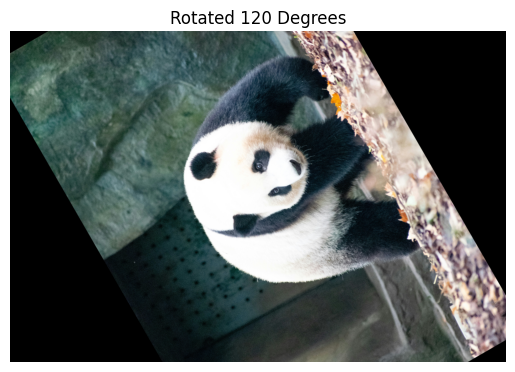

In [4]:
# Task 1.2: Rotate image by 120 degrees
(h, w) = img.shape[:2]
center = (w // 2, h // 2)
M_rot = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated_img = cv2.warpAffine(img, M_rot, (w, h))

plt.imshow(rotated_img)
plt.title("Rotated 120 Degrees")
plt.axis("off")
plt.show()


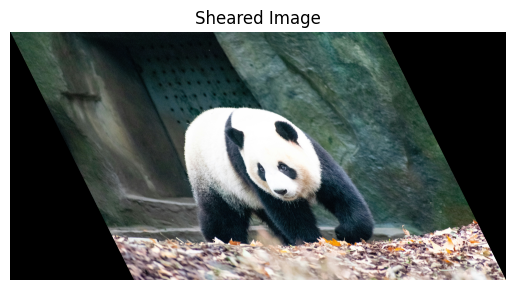

In [5]:
# Task 1.3: Shear operation
(h, w) = img.shape[:2]
shear_factor = 0.5
M_shear = np.float32([
    [1, shear_factor, 0],
    [0, 1, 0]
])
new_w = int(w + abs(shear_factor) * h)
sheared_img = cv2.warpAffine(img, M_shear, (new_w, h))

plt.imshow(sheared_img)
plt.title("Sheared Image")
plt.axis("off")
plt.show()


## Task 2: Intensity Transformations

In [6]:
# Prepare normalized float image for intensity transformations
img_float = img.astype(np.float32) / 255.0


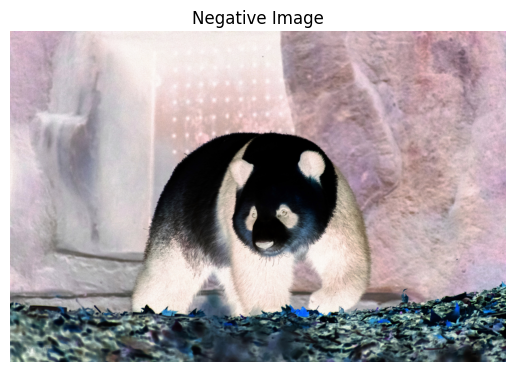

In [7]:
# Task 2.1: Negative transformation
negative = 1.0 - img_float

plt.imshow(negative)
plt.title("Negative Image")
plt.axis("off")
plt.show()


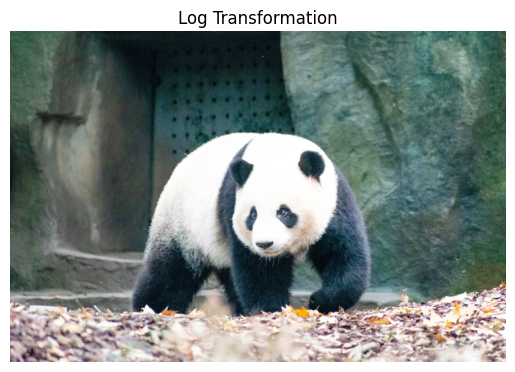

In [8]:
# Task 2.2: Log transformation
c = 1.0 / np.log(1.0 + np.max(img_float))
log_img = c * np.log(1.0 + img_float)

plt.imshow(log_img)
plt.title("Log Transformation")
plt.axis("off")
plt.show()


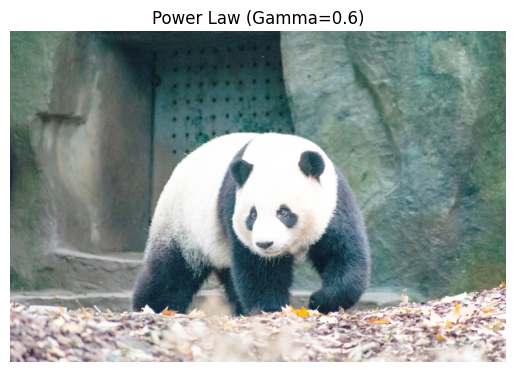

In [9]:
# Task 2.3: Power-law transformation (gamma < 1 increases brightness/contrast)
gamma = 0.6
power_img = np.power(img_float, gamma)

plt.imshow(power_img)
plt.title(f"Power Law (Gamma={gamma})")
plt.axis("off")
plt.show()
